In [46]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score




# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "Yellow-Trip-Data.csv"
OBESITY_URL = "Obesity-Level-Prediction-Dataset.csv"

In [47]:
### Section 1 — Supervised Learning: Regression

### Part 1.1 — Load and explore the taxi data


# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)


# TODO: Inspect it
taxi.shape
# taxi.head()
# taxi.info()
# taxi.describe()
taxi.tip_amount.describe()
print(f"Total missing values: \n \n {taxi.isna().sum()}")


# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

# tip_amt_plt = sns.load_dataset("taxi")
# sns.histplot(taxi, x="tip_amount", kde=True)


Total missing values: 
 
 VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** The data has 41,202 rows of data, spanning across 13 different columns/attributes. There aren't any missing values for any of the columns. When it comes to the tip amount, it's distribution is right-skewed, with the majority of the tips being between 14 and 20

In [48]:
### Part 1.2 - Preprocessing and feature engineering


# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi[(taxi['trip_distance'] > 0) & (taxi['fare_amount'] > 0)]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
taxi = pd.get_dummies(taxi, columns=['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'PULocationID', 'DOLocationID'], drop_first=True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** So we actually had no missing/invalid values so that was a breeze. The new feature we engineered was fare per mile, which is the fare amount divided by the trip distance


In [49]:
### Part 1.3 - Train / Validation / Test split


# TODO: Separate features (X) and target (y = tip_amount)
x = taxi.drop(columns=['tip_amount']) # Representing every column except the target
y = taxi['tip_amount'] # Just the target

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42, shuffle=True)


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)


sc = StandardScaler()

# Defining our numeric columns to fit the scalar on ONLY those, since the rest are just categorical and are in O's and 1's, it will be unnecessary to fit it on those as well
numeric_cols = ['trip_distance', 'fare_amount', 'passenger_count', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'fare_per_mile']

x_train[numeric_cols] = sc.fit_transform(x_train[numeric_cols]) # Scaling on just training

# Transform just val & test
x_val[numeric_cols] = sc.transform(x_val[numeric_cols])
x_test[numeric_cols] = sc.transform(x_test[numeric_cols])


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** For the split between train, test and val, I used the 60/20/20, which is quite common in dataset splitting. The other common ratio is 80/20 (that's assuming you're just working with training and validation) but since we have all 3, we went with the former. A separate validation set is useful in this scenario because, that's what we'll be using for our tuning based on performances. If we used our test set, we'll be leaking decisions from it and we don't want that, that's why there's a separate validation batch. Scaling, first of all, allows us to put all values on equal footing, so that the model learns on actual predictive signal, not just based on how large the numbers are. Scaling on just the training batch on the other hand, is done so that we don't leak data the model doesn't know from the test into the training, otherwise the model would perform better than expected on the test, which is not what we want.


R-Mean Squared Error (RMSE) for training (Linear Reg.): 4.7764
R-Mean Squared Error (RMSE) for validation (Linear Reg.): 5.0465
R-Mean Squared Error (RMSE) for testing (Linear Reg.): 5.0169
R-squared Score (R2) for training (Linear Reg.): 0.0624
R-squared Score (R2) for validation (Linear Reg.): 0.0451
R-squared Score (R2) for testing (Linear Reg.): 0.0496
---------------------------------------------------------------
R-Mean Squared Error (RMSE) for training (RandomForest Reg.): 2.8459
R-Mean Squared Error (RMSE) for validation (RandomForest Reg.): 5.6530
R-Mean Squared Error (RMSE) for testing (RandomForest Reg.): 5.6188
R-squared Score (R2) for training (RandomForest Reg.): 0.6671
R-squared Score (R2) for validation (RandomForest Reg.): -0.1982
R-squared Score (R2) for testing (RandomForest Reg.): -0.1921


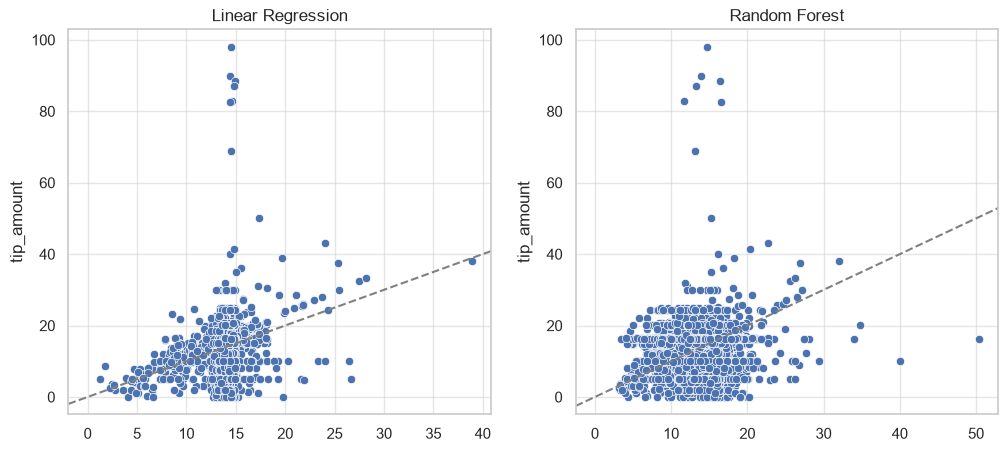

In [50]:
### Part 1.4 - Train a regressor and check for overfitting


# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# Setting up both Linear and RandomForest for comparison
model = LinearRegression()
model_2 = RandomForestRegressor()

model.fit(x_train, y_train)
model_2.fit(x_train, y_train)

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)
y_test_pred = model.predict(x_test)

y_train_pred_2 = model_2.predict(x_train)
y_val_pred_2 = model_2.predict(x_val)
y_test_pred_2 = model_2.predict(x_test)

print(f"R-Mean Squared Error (RMSE) for training (Linear Reg.): {mean_squared_error(y_train, y_train_pred) ** 0.5:.4f}")
print(f"R-Mean Squared Error (RMSE) for validation (Linear Reg.): {mean_squared_error(y_val, y_val_pred) ** 0.5:.4f}")
print(f"R-Mean Squared Error (RMSE) for testing (Linear Reg.): {mean_squared_error(y_test, y_test_pred) ** 0.5:.4f}")

print(f"R-squared Score (R2) for training (Linear Reg.): {r2_score(y_train, y_train_pred):.4f}")
print(f"R-squared Score (R2) for validation (Linear Reg.): {r2_score(y_val, y_val_pred):.4f}")
print(f"R-squared Score (R2) for testing (Linear Reg.): {r2_score(y_test, y_test_pred):.4f}")

print("---------------------------------------------------------------")

print(f"R-Mean Squared Error (RMSE) for training (RandomForest Reg.): {mean_squared_error(y_train, y_train_pred_2) ** 0.5:.4f}")
print(f"R-Mean Squared Error (RMSE) for validation (RandomForest Reg.): {mean_squared_error(y_val, y_val_pred_2) ** 0.5:.4f}")
print(f"R-Mean Squared Error (RMSE) for testing (RandomForest Reg.): {mean_squared_error(y_test, y_test_pred_2) ** 0.5:.4f}")

print(f"R-squared Score (R2) for training (RandomForest Reg.): {r2_score(y_train, y_train_pred_2):.4f}")
print(f"R-squared Score (R2) for validation (RandomForest Reg.): {r2_score(y_val, y_val_pred_2):.4f}")
print(f"R-squared Score (R2) for testing (RandomForest Reg.): {r2_score(y_test, y_test_pred_2):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_test_pred, y=y_test, ax=axes[0])
axes[0].axline((0, 0), slope=1, color="gray", linestyle="--")
axes[0].set_title("Linear Regression")

sns.scatterplot(x=y_test_pred_2, y=y_test, ax=axes[1])
axes[1].axline((0, 0), slope=1, color="gray", linestyle="--")
axes[1].set_title("Random Forest")

plt.show()



**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** Although the LinearRegression model was more general regarding the test numbers, they both weren't great, with the LinearRegression model underfitting (we can see this with our R-squared values close to zero [0.0624, 0.0451 and 0.0496] respectively), and the RandomForestRegressor model even being worse, with its numbers showing us that it is actually overfitting because the model at its default settings is too complex for the actual signal patterns in the data (The gap between training and test/val is too huge [0.6677, -0.2051 and -0.1933]). It just goes to show that both models can't be used for real-world tip prediction. The sweet spot would be somewhere in between the two.
